In [1]:
import pandas as pd
import duckdb
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect('../data/processed/biocascade.db')
df = con.execute("SELECT * FROM feature_matrix_raw").df()

# Define the 30 features used in your revamped model
features = [
    'age', 'gender', 'systolic_bp', 'diastolic_bp', 'pulse_pressure', 
    'mean_arterial_pressure', 'bmi', 'waist_cm', 'waist_height_ratio', 
    'hba1c', 'fasting_glucose', 'triglycerides', 'hdl_cholesterol', 
    'serum_creatinine', 'egfr', 'bun', 'bun_cr_ratio', 'uric_acid', 
    'sodium', 'potassium', 'hscrp', 'neutrophil_lymphocyte_ratio', 
    'hemoglobin', 'hematocrit', 'rdw', 'mets_score', 'cmi', 
    'vasc_metabolic_load', 'metabolic_renal_stress'
]

X = df[features].fillna(df[features].median())
y = df['is_high_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Training on {len(X_train)} patients | Testing on {len(X_test)} patients")

📊 Training on 3658 patients | Testing on 915 patients


In [2]:
# Initialize the high-performance model
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]

print("✅ BioCascade Model Training Complete.")

✅ BioCascade Model Training Complete.


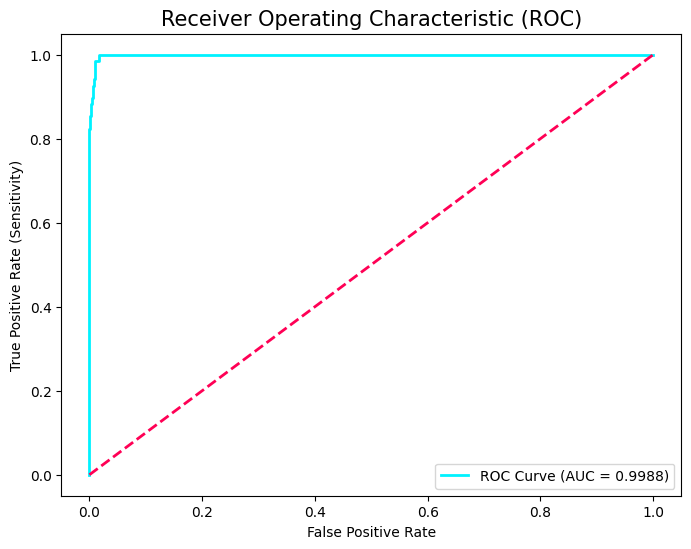

In [3]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#00f2ff', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='#ff0055', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)', fontsize=15)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend(loc="lower right")
plt.show()

/var/folders/nl/h26pjg8d0895c_2dhjdhk5qc0000gn/T/ipykernel_17564/3050163068.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(10), x='importance', y='feature', palette='viridis')


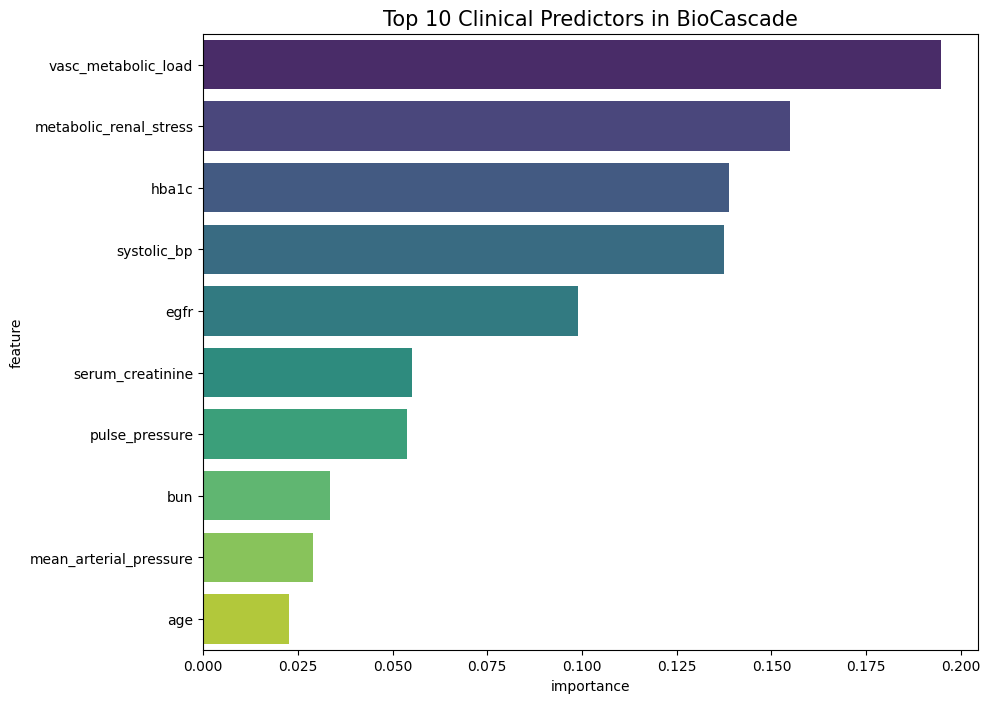

In [4]:
importances = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importances.head(10), x='importance', y='feature', palette='viridis')
plt.title('Top 10 Clinical Predictors in BioCascade', fontsize=15)
plt.show()